Loaded cube shape: (11765, 250, 256)
Assigned wavelengths. First 10: [0.8        0.81647059 0.83294118 0.84941176 0.86588235 0.88235294
 0.89882353 0.91529412 0.93176471 0.94823529]


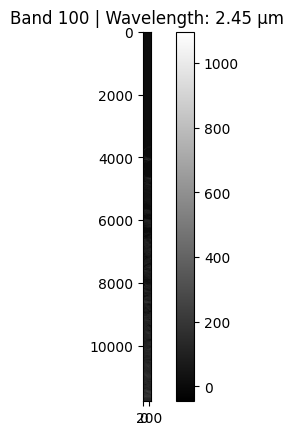

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spectral import io

# === Load Hyperspectral Image (.hdr + .qub) ===
hdr_path = r"C:\MAR TEST\cic test\CHIMG\data\calibrated\20231215\ch2_iir_nci_20231215T0748229155_d_img_d18.hdr"
qub_path = r"C:\MAR TEST\cic test\CHIMG\data\calibrated\20231215\ch2_iir_nci_20231215T0748229155_d_img_d18.qub"

# Load the hyperspectral image using Spectral Python
iirs_img = io.envi.open(hdr_path, image=qub_path)
cube = np.asarray(iirs_img.load())
print("Loaded cube shape:", cube.shape)

# === Assign Standard Wavelengths ===
wavelengths = np.linspace(0.8, 5.0, cube.shape[2])
print("Assigned wavelengths. First 10:", wavelengths[:10])

# === Visualize One Band ===
band_index = 100
plt.imshow(cube[:, :, band_index], cmap='gray')
plt.title(f"Band {band_index} | Wavelength: {wavelengths[band_index]:.2f} µm")
plt.colorbar()
plt.show()

In [ ]:
# === Rule-Based Labeling ===
def find_band(wavelengths, target):
    return int(np.argmin(np.abs(np.array(wavelengths) - target)))

def classify_pixel(spectrum, wavelengths):
    if spectrum.size == 0:
        return 0
    spectrum = np.asarray(spectrum).squeeze()
    mean_val = np.mean(spectrum)
    std_val = np.std(spectrum)
    try:
        if spectrum[find_band(wavelengths, 3.0)] < mean_val * 0.85:
            return 1
        if (spectrum[find_band(wavelengths, 1.05)] < mean_val * 0.85 and spectrum[find_band(wavelengths, 2.0)] < mean_val * 0.85):
            return 2
        if spectrum[-1] > mean_val + 2 * std_val:
            return 3
        if (spectrum[find_band(wavelengths, 2.7)] < mean_val * 0.85 or spectrum[find_band(wavelengths, 4.3)] < mean_val * 0.85):
            return 4
    except (IndexError, ValueError):
        return 0
    return 0

In [ ]:
# === Apply Classification ===
height, width, bands = cube.shape
label_map = np.zeros((height, width), dtype=np.uint8)
class_points = []

print("Running classification... This may take a few minutes.")
for i in range(height):
    for j in range(width):
        spectrum = cube[i, j, :]
        label = classify_pixel(spectrum, wavelengths)
        label_map[i, j] = label
        if label > 0:
            x = j
            y = i
            class_points.append((x, y, label))
print("Classification complete.")

Running classification... This may take a few minutes.
Classification complete.


In [ ]:
# === Ensure output folder exists ===
output_dir = r"C:\MAR TEST\cic test\CHIMG\results"
os.makedirs(output_dir, exist_ok=True)

# === Export Classified Map as GeoTIFF ===
import rasterio
from rasterio.transform import from_origin

transform = from_origin(0, 0, 1, 1)
output_path = os.path.join(output_dir, "classified_map.tif")

with rasterio.open(
    output_path,
    "w",
    driver="GTiff",
    height=label_map.shape[0],
    width=label_map.shape[1],
    count=1,
    dtype=rasterio.uint8,
    crs="EPSG:4326",
    transform=transform,
) as dst:
    dst.write(label_map, 1)
print(f"GeoTIFF exported to: {output_path}")

GeoTIFF exported to: C:\MAR TEST\cic test\CHIMG\results\classified_map.tif


C:\Program Files\Python310\lib\site-packages\rasterio\__init__.py:378: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(


In [ ]:

# === Export CSV of Class Points ===
import pandas as pd

csv_path = os.path.join(output_dir, "classified_points.csv")
df = pd.DataFrame(class_points, columns=["x", "y", "label"])
df.to_csv(csv_path, index=False)
print(f"CSV of classified coordinates exported to: {csv_path}")


CSV of classified coordinates exported to: C:\MAR TEST\cic test\CHIMG\results\classified_points.csv


In [ ]:

# === Cluster Analysis to Find High-Concentration Zones ===
from sklearn.cluster import DBSCAN

high_density_coords = []
centroid_coords = []

for class_id in [1, 2, 3, 4]:
    class_df = df[df['label'] == class_id][['x', 'y']]
    if not class_df.empty:
        clustering = DBSCAN(eps=10, min_samples=5).fit(class_df)
        df.loc[class_df.index, f'cluster_{class_id}'] = clustering.labels_

        clustered = class_df.copy()
        clustered['label'] = class_id
        clustered['cluster'] = clustering.labels_
        clustered = clustered[clustered['cluster'] != -1]
        high_density_coords.extend(clustered.values.tolist())

        # compute centroids
        grouped = clustered.groupby('cluster')
        for cluster_id, group in grouped:
            cx, cy = group['x'].mean(), group['y'].mean()
            centroid_coords.append((cx, cy, class_id, cluster_id))



In [ ]:
# === Export high-density cluster points and centroids ===
high_density_csv = os.path.join(output_dir, "high_density_clusters.csv")
high_density_df = pd.DataFrame(high_density_coords, columns=["x", "y", "label", "cluster"])
high_density_df.to_csv(high_density_csv, index=False)
print(f"High-density cluster coordinates exported to: {high_density_csv}")

centroids_csv = os.path.join(output_dir, "cluster_centroids.csv")
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "cluster"])
centroid_df.to_csv(centroids_csv, index=False)
print(f"Centroids of clusters exported to: {centroids_csv}")


High-density cluster coordinates exported to: C:\MAR TEST\cic test\CHIMG\results\high_density_clusters.csv
Centroids of clusters exported to: C:\MAR TEST\cic test\CHIMG\results\cluster_centroids.csv


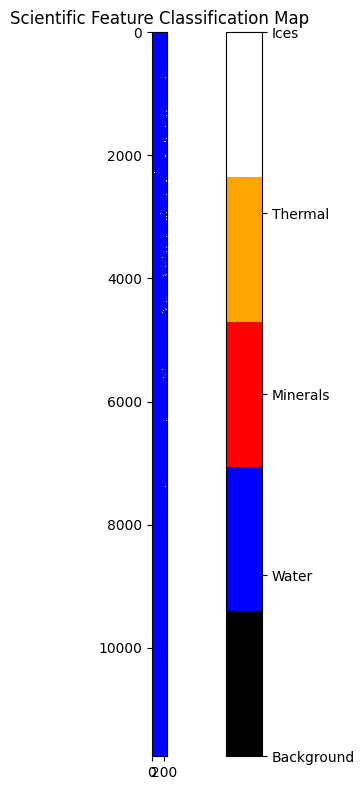

In [ ]:
# === Visualize Label Map ===
import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'white'])
labels = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

C:\Program Files\Python310\lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


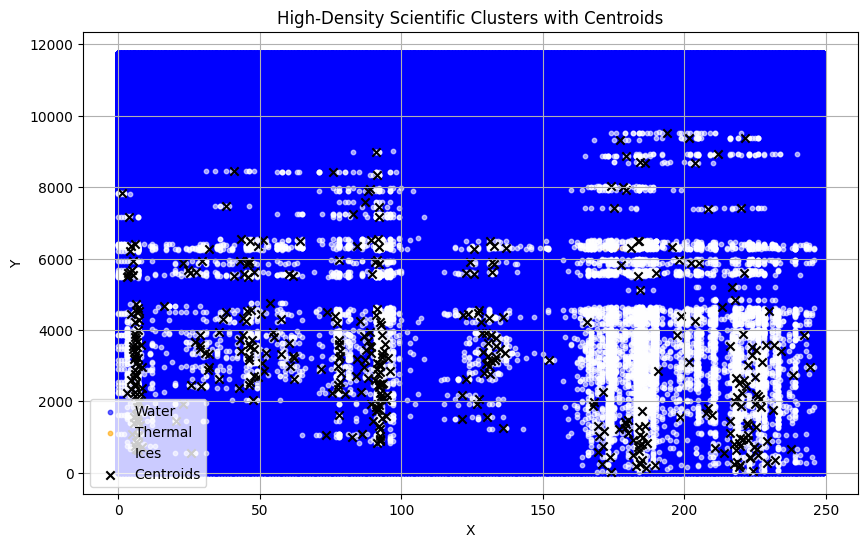

In [ ]:
# === Visualize Label Map ===

# === Visualize and Save Cluster Plot with Centroids ===
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'white']
labels_map = {1: 'Water', 2: 'Minerals', 3: 'Thermal', 4: 'Ices'}

for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        ax.scatter(subset['x'], subset['y'], s=10, label=labels_map[class_id], alpha=0.6, c=color)

# overlay centroids
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "cluster"])
ax.scatter(centroid_df['x'], centroid_df['y'], marker='x', c='black', label='Centroids')

ax.legend()
ax.set_title("High-Density Scientific Clusters with Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()

# Save cluster visualization with centroids
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
print(f"Cluster visualization saved to: {cluster_png}")
plt.show()

# === Visualize Label Map ===
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'cyan'])  # changed 'white' to 'cyan' to fix overlap with background # updated
labels = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.show()

# === Visualize and Save Cluster Plot with Centroids ===
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'white']
labels_map = {1: 'Water', 2: 'Minerals', 3: 'Thermal', 4: 'Ices'}

for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        ax.scatter(subset['x'], subset['y'], s=10, label=labels_map[class_id], alpha=0.6, c=color)

# overlay centroids
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "cluster"])
ax.scatter(centroid_df['x'], centroid_df['y'], marker='x', c='black', label='Centroids')

ax.legend()
ax.set_title("High-Density Scientific Clusters with Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()

# Save cluster visualization with centroids
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
print(f"Cluster visualization saved to: {cluster_png}")
plt.show()


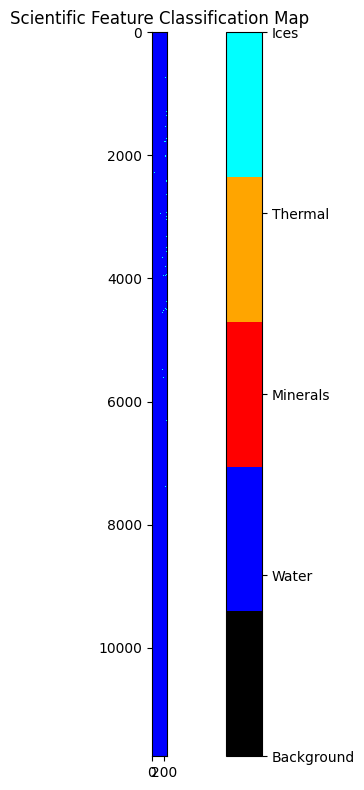

C:\Users\ENVY\AppData\Local\Temp\ipykernel_31644\2478676621.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\ENVY\AppData\Local\Temp\ipykernel_31644\2478676621.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(cluster_png)


Cluster visualization saved to: C:\MAR TEST\cic test\CHIMG\results\high_density_clusters.png


C:\Program Files\Python310\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


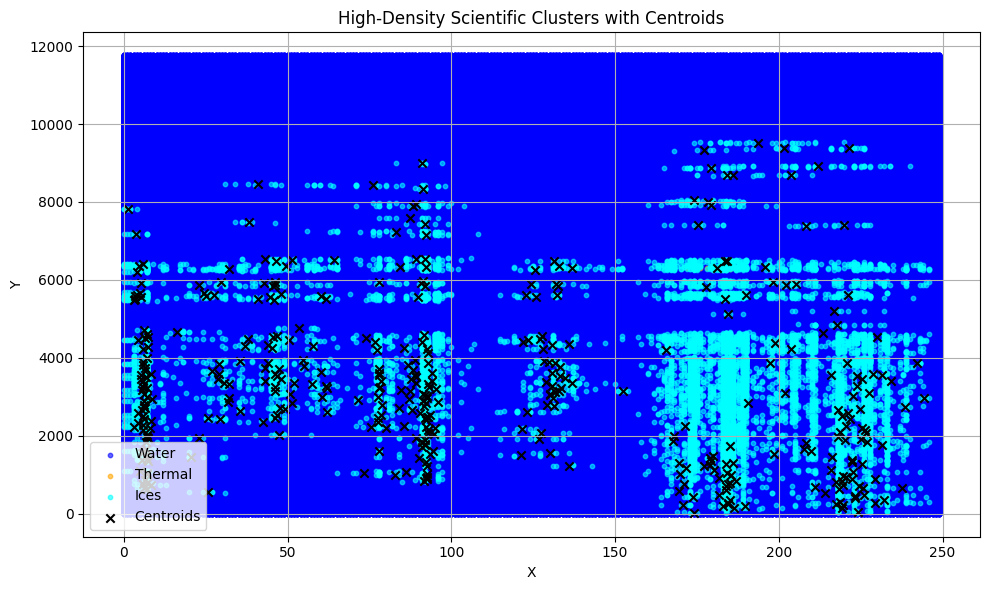

In [ ]:
# === Visualize Label Map ===

# Duplicate cluster plot block removed to avoid conflicting color definitions # updated

# === Visualize Label Map ===
import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap(['black', 'blue', 'red', 'orange', 'cyan'])  # changed 'white' to 'cyan' to fix overlap with background # updated
labels = ['Background', 'Water', 'Minerals', 'Thermal', 'Ices']

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(label_map, cmap=cmap, interpolation='nearest')
cbar = plt.colorbar(im, ticks=range(5), ax=ax)
cbar.ax.set_yticklabels(labels)
plt.title("Scientific Feature Classification Map")
plt.tight_layout()
plt.show()

# === Visualize and Save Cluster Plot with Centroids ===
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'red', 'orange', 'cyan']  # changed 'white' to 'cyan' to distinguish Ices from background # this changed
labels_map = {1: 'Water', 2: 'Minerals', 3: 'Thermal', 4: 'Ices'}

for class_id, color in zip([1, 2, 3, 4], colors):
    subset = high_density_df[high_density_df['label'] == class_id]
    if not subset.empty:
        ax.scatter(subset['x'], subset['y'], s=10, label=labels_map[class_id], alpha=0.6, c=color)

# overlay centroids
centroid_df = pd.DataFrame(centroid_coords, columns=["x", "y", "label", "cluster"])
ax.scatter(centroid_df['x'], centroid_df['y'], marker='x', c='black', label='Centroids')

ax.legend()
ax.set_title("High-Density Scientific Clusters with Centroids")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.tight_layout()

# Save cluster visualization with centroids
cluster_png = os.path.join(output_dir, "high_density_clusters.png")
plt.savefig(cluster_png)
print(f"Cluster visualization saved to: {cluster_png}")
plt.show()


In [ ]:
# === Step 7: Export for GIS Use ===

# Define lunar and fallback CRS
wgs_crs = "EPSG:4326"
lunar_proj = "+proj=longlat +a=1737400 +b=1737400 +no_defs"
import geopandas as gpd
from shapely.geometry import Point

# Export high-density clusters as shapefile
cluster_shapefile = os.path.join(output_dir, "high_density_clusters.shp")
geometry_clusters = [Point(xy) for xy in zip(high_density_df['x'], high_density_df['y'])]
gdf_clusters = gpd.GeoDataFrame(high_density_df, geometry=geometry_clusters)
try:
    gdf_clusters.set_crs(lunar_proj, inplace=True)
except:
    print("Falling back to WGS84")
    gdf_clusters.set_crs(wgs_crs, inplace=True)
gdf_clusters.to_file(cluster_shapefile)
print(f"Shapefile exported: {cluster_shapefile}")

# Export centroids as GeoJSON
centroid_geojson = os.path.join(output_dir, "cluster_centroids.geojson")
geometry_centroids = [Point(xy) for xy in zip(centroid_df['x'], centroid_df['y'])]
gdf_centroids = gpd.GeoDataFrame(centroid_df, geometry=geometry_centroids)
try:
    gdf_centroids.set_crs(lunar_proj, inplace=True)
except:
    print("Falling back to WGS84")
    gdf_centroids.set_crs(wgs_crs, inplace=True)
gdf_centroids.to_file(centroid_geojson, driver='GeoJSON')
print(f"GeoJSON exported: {centroid_geojson}")

Shapefile exported: C:\MAR TEST\cic test\CHIMG\results\high_density_clusters.shp
GeoJSON exported: C:\MAR TEST\cic test\CHIMG\results\cluster_centroids.geojson


In [ ]:
print("Centroid class counts:")
print(centroid_df['label'].value_counts())


Centroid class counts:
label
4    413
3      4
1      1
Name: count, dtype: int64
